In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.optimize import least_squares
import surfinBH
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
import lal
from tqdm.auto import tqdm
lal.swig_redirect_standard_output_error(False)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


True

In [2]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


In [3]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.30_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

### 2PN binding energy and total angular momentum

In this cell we construct a reduced circular-orbit PN model for the conservative binding energy and the total angular momentum of a compact binary system up to 2PN order, keeping explicit powers of the speed of light $c$. We introduce the PN bookkeeping parameter

$$
\epsilon = \frac{1}{c}.
$$

The standard dimensionless PN parameter is

$$
x_{\rm PN}
=
\left(
\frac{Gm\Omega}{c^3}
\right)^{2/3},
$$

where $\Omega$ is the orbital frequency and $m=m_1+m_2$ is the total mass. In the symbolic calculation we introduce the rescaled variable

$$
X = c^2 x_{\rm PN},
$$

so that

$$
x_{\rm PN}
=
\frac{X}{c^2}
=
X\epsilon^2.
$$

The mass parameters are

$$
m=m_1+m_2,
\qquad
\mu=\frac{m_1m_2}{m},
\qquad
\nu=\frac{\mu}{m}.
$$

The non-spinning circular binding energy up to 2PN order is

$$
E_{\rm NS}(X)
=
-\frac{\mu X}{2}
\left[
1+
\left(
-\frac{3}{4}
-\frac{\nu}{12}
\right)
\frac{X}{c^2}
+
\left(
-\frac{27}{8}
+
\frac{19}{8}\nu
-
\frac{\nu^2}{24}
\right)
\frac{X^2}{c^4}
\right].
$$

Equivalently,

$$
E_{\rm NS}(X)
=
-\frac{\mu X}{2}
+
\frac{\mu X^2}{24c^2}
\left(
9+\nu
\right)
+
\frac{\mu X^3}{48c^4}
\left(
81-57\nu+\nu^2
\right).
$$

The leading spin-orbit contribution enters at 1.5PN order. Defining

$$
B_{\rm SO}
=
S_{1L}
\left(
4m_1m_2+3m_2^2
\right)
+
S_{2L}
\left(
3m_1^2+4m_1m_2
\right),
$$

we use

$$
E_{\rm SO}^{1.5{\rm PN}}(X)
=
-
\frac{\mu X^{5/2}}{3Gm^2m_1m_2c^3}
B_{\rm SO}.
$$

The leading spin-spin sector enters at 2PN order. It contains both the mutual interaction $S_1S_2$ and the self-spin, or spin-induced quadrupole, terms. For the mutual term we define

$$
B_{\rm SS}^{12}
=
-\mathbf S_1\cdot\mathbf S_2
+
3S_{1L}S_{2L},
$$

so that

$$
E_{\rm SS}^{12}(X)
=
-
\frac{X^3}{2G^2m^3c^4}
B_{\rm SS}^{12}.
$$

For the self-spin terms we define

$$
B_{\rm SS}^{11}
=
-\mathbf S_1^2
+
3S_{1L}^2,
\qquad
B_{\rm SS}^{22}
=
-\mathbf S_2^2
+
3S_{2L}^2.
$$

For Kerr black holes the spin-induced quadrupole coefficients are fixed to

$$
C_{Q1}=C_{Q2}=1.
$$

Therefore, the Kerr self-spin contribution is

$$
E_{\rm SS}^{\rm self}(X)
=
-
\frac{X^3}{4G^2m^3c^4}
\left[
\frac{m_2}{m_1}
B_{\rm SS}^{11}
+
\frac{m_1}{m_2}
B_{\rm SS}^{22}
\right].
$$

The conservative binding energy used in this cell is therefore

$$
E_{\rm bind}(X)
=
E_{\rm NS}(X)
+
E_{\rm SO}^{1.5{\rm PN}}(X)
+
E_{\rm SS}^{12}(X)
+
E_{\rm SS}^{\rm self}(X).
$$

The non-spinning orbital angular momentum up to 2PN order is

$$
L_{\rm NS}(X)
=
\frac{G\mu m}{\sqrt X}
\left[
1+
\left(
\frac{3}{2}
+
\frac{\nu}{6}
\right)
\frac{X}{c^2}
+
\left(
\frac{27}{8}
-
\frac{19}{8}\nu
+
\frac{\nu^2}{24}
\right)
\frac{X^2}{c^4}
\right].
$$

The leading spin-orbit correction to the orbital angular momentum enters at 1.5PN order. Its components on the orbital triad $(\mathbf n,\boldsymbol{\lambda},\boldsymbol{\ell})$ are

$$
L_{\ell,{\rm SO}}^{1.5{\rm PN}}
=
-
\frac{5X}{6m^2c^3}
B_{\rm SO},
$$

$$
L_{n,{\rm SO}}^{1.5{\rm PN}}
=
\frac{X}{2m^2c^3}
\left(
m_2^2S_{1n}
+
m_1^2S_{2n}
\right),
$$

$$
L_{\lambda,{\rm SO}}^{1.5{\rm PN}}
=
-
\frac{X}{m^2c^3}
\left[
m_2(2m_1+m_2)S_{1\lambda}
+
m_1(m_1+2m_2)S_{2\lambda}
\right].
$$

The spins are decomposed on the orbital triad as

$$
\mathbf S_i
=
S_{in}\mathbf n
+
S_{i\lambda}\boldsymbol{\lambda}
+
S_{iL}\boldsymbol{\ell}.
$$

The total angular momentum is constructed as the reduced circular-orbit PN quantity

$$
\mathbf J
=
\mathbf L_{\rm NS}
+
\mathbf L_{\rm SO}^{1.5{\rm PN}}
+
\frac{\mathbf S_1+\mathbf S_2}{c}.
$$

Therefore,

$$
J_\ell
=
L_{\rm NS}
+
L_{\ell,{\rm SO}}^{1.5{\rm PN}}
+
\frac{S_{1L}+S_{2L}}{c},
$$

$$
J_n
=
L_{n,{\rm SO}}^{1.5{\rm PN}}
+
\frac{S_{1n}+S_{2n}}{c},
$$

$$
J_\lambda
=
L_{\lambda,{\rm SO}}^{1.5{\rm PN}}
+
\frac{S_{1\lambda}+S_{2\lambda}}{c}.
$$

The scalar angular momentum used in the Kerr entropy is

$$
J_{\rm tot}
=
\sqrt{
J_\ell^2
+
J_n^2
+
J_\lambda^2
}.
$$

This construction should be interpreted carefully. In the full canonical Hamiltonian formulation, the angular-momentum generator has the structure

$$
\mathbf J_{\rm can}
=
\mathbf r\times\mathbf p
+
\mathbf S_1
+
\mathbf S_2.
$$

Spin-spin and spin-induced quadrupole effects enter the Hamiltonian and modify the circular-orbit relations between $\mathbf r$, $\mathbf p$, $\Omega$, $E$, and $J$. In this reduced implementation we do not add an independent explicit spin-spin angular-momentum vector by hand. Instead, we construct $\mathbf J$ from the PN-corrected non-spinning orbital angular momentum, the leading spin-orbit correction, and the spin contribution. Spin-quadratic terms can still enter the scalar quantity $J_{\rm tot}$ through the norm of the total vector.

Thus, this cell implements a circular-orbit PN reduction of the conservative dynamics through 2PN order. The binding energy contains the point-particle sector up to 2PN, the leading spin-orbit term at 1.5PN, and the leading spin-spin sector at 2PN, including Kerr self-spin/quadrupole terms. The angular momentum is the PN-consistent reduced angular momentum used for the entropy calculation, not a separately derived full canonical 2PN angular-momentum expansion.

This model is conservative and circular-orbit based. It does not include radiation reaction, eccentric corrections, higher-PN spin terms, merger, or ringdown physics. It should also be distinguished from the numerical implementation written in terms of the radial PN parameter

$$
\Gamma
=
\frac{Gm}{r},
$$

whose coefficients differ from the $X=c^2x_{\rm PN}$ expansion beyond Newtonian order.

**References**

- L. Blanchet, *Post-Newtonian Theory for Gravitational Waves*, Living Reviews in Relativity **17**, 2 (2014), arXiv:1310.1528.
- L. E. Kidder, *Coalescing binary systems of compact objects to post-Newtonian 5/2 order. V. Spin effects*, Physical Review D **52**, 821 (1995), arXiv:gr-qc/9506022.

In [4]:
c = sp.Symbol('c', positive=True)
eps = sp.Symbol('eps', positive=True)   
G = sp.Symbol('G', real=True, positive=True)
nu = sp.Symbol(r'\nu', real=True, positive=True)
mu = sp.Symbol(r'\mu', real=True, positive=True)
m = sp.Symbol('m', real=True, positive=True)
m1, m2 = sp.symbols('m_1 m_2', positive=True)


S1n, S2n = sp.symbols(r'S_{1n} S_{2n}', real=True)
S1lam, S2lam = sp.symbols(r'S_{1\lambda} S_{2\lambda}', real=True)
S1L, S2L = sp.symbols(r'S_{1L} S_{2L}', real=True)
S1S2 = S1n*S2n + S1lam*S2lam + S1L*S2L
S1sq = S1n**2 + S1lam**2 + S1L**2
S2sq = S2n**2 + S2lam**2 + S2L**2

CQ1 = sp.Integer(1)
CQ2 = sp.Integer(1)

X = sp.Symbol('X', real=True, positive=True)
x_val = X * eps**2

e1 = -sp.Rational(3, 4) - nu/12

e2 = (-sp.Rational(27, 8)+ sp.Rational(19, 8)*nu- nu**2/24)
j1 = sp.Rational(3, 2) + nu/6
j2 = (sp.Rational(27, 8)- sp.Rational(19, 8)*nu+ nu**2/24)
E_NS = -(mu * (1/eps)**2 * x_val / 2) * (1 + e1*x_val + e2*x_val**2)
L_NS = (G * mu * m / ((1/eps) * sp.sqrt(x_val))) * (1 + j1*x_val + j2*x_val**2)
E_NS = sp.expand(E_NS)
L_NS = sp.expand(L_NS)
B_SO_L = (S1L * (4*m1*m2 + 3*m2**2)+S2L * (3*m1**2 + 4*m1*m2))
E_SO_15PN = -(mu * (1/eps)**2 * x_val**sp.Rational(5, 2)) / (3 * G * m**2 * m1 * m2) * B_SO_L
L_SO_ell_15PN = -(sp.Rational(5, 6)* X* eps**3/ m**2) * B_SO_L
L_SO_n_15PN = (X* eps**3/ (2*m**2)) * (m2**2*S1n+m1**2*S2n)
L_SO_lam_15PN = -(X* eps**3/ m**2) * (m2*(2*m1 + m2)*S1lam+m1*(m1 + 2*m2)*S2lam)
B_SS_12 = -S1S2 + 3*S1L*S2L
E_SS_12_2PN = -(X**3 * eps**4) / (2 * G**2 * m**3) * B_SS_12
B_SS_11 = -S1sq + 3*S1L**2
B_SS_22 = -S2sq + 3*S2L**2
E_SS_self_2PN = -(X**3 * eps**4) / (4 * G**2 * m**3) * (CQ1 * (m2/m1) * B_SS_11+CQ2 * (m1/m2) * B_SS_22)

E_bind = (E_NS+E_SO_15PN+E_SS_12_2PN+E_SS_self_2PN)

L_ell = L_NS + L_SO_ell_15PN
L_n = L_SO_n_15PN
L_lam = L_SO_lam_15PN
J_ell = L_ell + eps*(S1L + S2L)
J_n = L_n + eps*(S1n + S2n)
J_lam = L_lam + eps*(S1lam + S2lam)
J_tot = sp.sqrt(J_ell**2+J_n**2+J_lam**2)

E_bind_eps = sp.series(E_bind, eps, 0, 5).removeO()
J_tot_eps = sp.series(J_tot, eps, 0, 5).removeO()

def get_eps_terms(expr, max_power=4):
    expr = sp.expand(expr)
    terms = {}
    for power in range(max_power + 1):
        coeff = expr.coeff(eps, power)
        if coeff != 0:
            terms[power] = sp.simplify(coeff)
    return terms

def pn_label_from_eps_power(power):
    labels = {
        0: r"\mathrm{N}",
        1: r"S/c",
        2: r"1\mathrm{PN}",
        3: r"1.5\mathrm{PN}",
        4: r"2\mathrm{PN}",
    }
    return labels.get(power, rf"\epsilon^{power}")

def display_pn_terms(name, expr_eps, max_power=4):
    terms = get_eps_terms(expr_eps, max_power=max_power)
    lines = []
    total_terms = []
    for power, coeff in terms.items():
        term_with_c = coeff / c**power
        total_terms.append(term_with_c)
        label = pn_label_from_eps_power(power)
        lines.append(rf"{name}_{{{label}}} &= {sp.latex(term_with_c)}")
    total_expr = sp.Add(*total_terms, evaluate=False)
    lines.append(rf"{name} &= {sp.latex(total_expr)}")
    latex_str = r"\begin{aligned}" + r"\\".join(lines) + r"\end{aligned}"
    display(Math(latex_str))
    print("\n" + "-"*80 + "\n")

print(r"1. Total binding energy up to 2PN:" + "\n")
display_pn_terms(r"E_{\rm bind}(X)", E_bind_eps, max_power=4)

print(r"2. Total angular momentum up to 2PN:" + "\n")
display_pn_terms(r"J_{\rm tot}(X)", J_tot_eps, max_power=4)

1. Total binding energy up to 2PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------

2. Total angular momentum up to 2PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------



In [5]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [6]:
def get_2PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")
    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")

    CQ1 = 1.0
    CQ2 = 1.0
    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)
    a_prec, th1, th2, dphi = np.broadcast_arrays(a_prec,th1,th2,dphi)

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")
    
    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)
    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2
    S1n = S1_mag * np.sin(th1)
    S1lam = np.zeros_like(th1)
    S1L = S1_mag * np.cos(th1)
    S2n = S2_mag * np.sin(th2) * np.cos(dphi)
    S2lam = S2_mag * np.sin(th2) * np.sin(dphi)
    S2L = S2_mag * np.cos(th2)
    S1_vec = np.stack([S1n,S1lam,S1L],axis=-1)
    S2_vec = np.stack([S2n,S2lam,S2L],axis=-1)
    S_tot_vec = S1_vec + S2_vec
    S1S2 = np.sum(S1_vec * S2_vec, axis=-1)
    S1sq = np.sum(S1_vec * S1_vec, axis=-1)
    S2sq = np.sum(S2_vec * S2_vec, axis=-1)

    bracket_SO_L = (S1L * (4.0 * m1 * m2 + 3.0 * m2**2)+S2L * (3.0 * m1**2 + 4.0 * m1 * m2))
    bracket_Mutual_SS = -S1S2 + 3.0 * S1L * S2L
    bracket_Self_SS_1 = -S1sq + 3.0 * S1L**2
    bracket_Self_SS_2 = -S2sq + 3.0 * S2L**2

    E_bind_0PN = -0.5 * mu * Gamma
    E_bind_1PN = (mu * Gamma**2 * (7.0 - nu) / 8.0)
    E_bind_SO_15PN = -(mu * Gamma**2.5/ (3.0 * G * m**2 * m1 * m2)) * bracket_SO_L
    E_bind_2PN_NS = (mu * Gamma**3 * (7.0 - 49.0 * nu - nu**2) / 16.0)
    E_bind_SS_mutual_2PN = -(Gamma**3/ (2.0 * G**2 * m**3)) * bracket_Mutual_SS
    E_bind_SS_self_2PN = -(Gamma**3/ (4.0 * G**2 * m**3)) * (CQ1 * (m2 / m1) * bracket_Self_SS_1+CQ2 * (m1 / m2) * bracket_Self_SS_2)
    E_bind_SS_2PN = (E_bind_SS_mutual_2PN+E_bind_SS_self_2PN)
    E_bind = (E_bind_0PN+E_bind_1PN / c**2+E_bind_SO_15PN / c**3+(E_bind_2PN_NS+E_bind_SS_mutual_2PN+E_bind_SS_self_2PN) / c**4)
    E_tot = m + E_bind / c**2

    L_NS_0PN = G * mu * m / sqrt_Gamma
    L_NS_1PN = 2.0 * G * mu * m * sqrt_Gamma
    L_NS_2PN = (G * mu * m * Gamma**1.5 * (5.0 - 9.0 * nu) / 2.0)
    L_NS = (L_NS_0PN+L_NS_1PN / c**2+L_NS_2PN / c**4)
    L_SO_L_15PN = -(5.0 * Gamma/ (6.0 * m**2)) * bracket_SO_L
    L_SO_n_15PN = (Gamma/ (2.0 * m**2)) * (m2**2 * S1n+m1**2 * S2n)
    L_SO_lam_15PN = -(Gamma/ m**2) * (m2 * (2.0 * m1 + m2) * S1lam+m1 * (m1 + 2.0 * m2) * S2lam)
    L_n = L_SO_n_15PN / c**3
    L_lam = L_SO_lam_15PN / c**3
    L_ell = (L_NS+L_SO_L_15PN / c**3)
    L_vec = np.stack([L_n,L_lam,L_ell],axis=-1)
    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,

        "CQ1": CQ1,
        "CQ2": CQ2,

        "E_bind": E_bind,
        "E_tot": E_tot,

        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN": E_bind_1PN / c**2,
        "E_bind_SO_15PN": E_bind_SO_15PN / c**3,
        "E_bind_2PN_NS": E_bind_2PN_NS / c**4,

        "E_bind_SS_2PN": E_bind_SS_2PN / c**4,
        "E_bind_SS_mutual_2PN": E_bind_SS_mutual_2PN / c**4,
        "E_bind_SS_self_2PN": E_bind_SS_self_2PN / c**4,

        "L_vec": L_vec,
        "L_n": L_n,
        "L_lam": L_lam,
        "L_ell": L_ell,

        "L_NS": L_NS,
        "L_NS_0PN": L_NS_0PN,
        "L_NS_1PN": L_NS_1PN / c**2,
        "L_NS_2PN": L_NS_2PN / c**4,

        "L_SO_n_15PN": L_SO_n_15PN / c**3,
        "L_SO_lam_15PN": L_SO_lam_15PN / c**3,
        "L_SO_L_15PN": L_SO_L_15PN / c**3,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "S1S2": S1S2,
        "S1sq": S1sq,
        "S2sq": S2sq,

        "bracket_SO_L": bracket_SO_L,
        "bracket_Mutual_SS": bracket_Mutual_SS,
        "bracket_Self_SS_1": bracket_Self_SS_1,
        "bracket_Self_SS_2": bracket_Self_SS_2,

        "J_vec": J_vec,
        "J_tot": J_tot
    }

In [7]:
def get_merger_separation_NR(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01):

    q_prec = float(q_prec)
    chi1_0_vec = np.asarray(chi1_0_vec, dtype=float).flatten()
    chi2_0_vec = np.asarray(chi2_0_vec, dtype=float).flatten()

    if chi1_0_vec.shape != (3,):
        raise ValueError(f"chi1_0_vec must have shape (3,), got {chi1_0_vec.shape}.")
    if chi2_0_vec.shape != (3,):
        raise ValueError(f"chi2_0_vec must have shape (3,), got {chi2_0_vec.shape}.")
    if q_prec <= 0:
        raise ValueError("q_prec must be positive.")
    if q_prec <= 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec
    else:
        q_surr = q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec

    t, h, _ = sur_wave_precessing(q_surr,chi_surr_1,chi_surr_2,dt=0.1,f_low=f_low)
    amp_tot_sq = np.zeros_like(t, dtype=float)
    omega_orb_num = np.zeros_like(t, dtype=float)
    omega_orb_den = np.zeros_like(t, dtype=float)

    for mode, h_lm in h.items():

        ell, m = mode
        h_lm = np.asarray(h_lm, dtype=complex)
        amp_lm_sq = np.abs(h_lm)**2
        amp_tot_sq += amp_lm_sq
        if m == 0:
            continue
        phase_lm = np.unwrap(np.angle(h_lm))
        omega_lm = np.abs(np.gradient(phase_lm, t))
        omega_orb_lm = omega_lm / abs(m)
        omega_orb_num += amp_lm_sq * omega_orb_lm
        omega_orb_den += amp_lm_sq

    A_tot = np.sqrt(amp_tot_sq)
    omega_orb = np.full_like(t, np.nan, dtype=float)
    mask_omega = omega_orb_den > 0.0
    omega_orb[mask_omega] = omega_orb_num[mask_omega] / omega_orb_den[mask_omega]
    r_inst = np.full_like(t, np.nan, dtype=float)
    mask_r = np.isfinite(omega_orb) & (omega_orb > 0.0)
    r_inst[mask_r] = omega_orb[mask_r]**(-2.0 / 3.0)
    idx_merger = np.argmax(A_tot)
    r_merger = r_inst[idx_merger]

    if not np.isfinite(r_merger):
        finite_idx = np.where(np.isfinite(r_inst))[0]
        if len(finite_idx) == 0:
            raise RuntimeError("No finite effective separation could be computed.")
        nearest = finite_idx[np.argmin(np.abs(finite_idx - idx_merger))]
        r_merger = r_inst[nearest]

    return r_merger, t, r_inst

In [8]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [9]:
with open(file_path, 'r') as f:
    f.readline()
    header_line = f.readline()

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))

theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a_prec = df['separation_M'].to_numpy()
th1 = df['theta1_rad'].to_numpy()
th2 = df['theta2_rad'].to_numpy()
dphi = df['deltaphi_rad'].to_numpy()

chi1_0_x = chi1 * np.sin(theta1_0_rad) * np.cos(phi1_0_rad)
chi1_0_y = chi1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad)
chi1_0_z = chi1 * np.cos(theta1_0_rad)
chi1_0_vec = np.array([chi1_0_x, chi1_0_y, chi1_0_z])

chi2_0_x = chi2 * np.sin(theta2_0_rad) * np.cos(phi2_0_rad)
chi2_0_y = chi2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
chi2_0_z = chi2 * np.cos(theta2_0_rad)
chi2_0_vec = np.array([chi2_0_x, chi2_0_y, chi2_0_z])

chi1_x = chi1 * np.sin(th1)
chi1_y = np.zeros_like(th1)
chi1_z = chi1 * np.cos(th1)
chi1_vec = np.array([chi1_x, chi1_y, chi1_z])

chi2_x = chi2 * np.sin(th2) * np.cos(dphi)
chi2_y = chi2 * np.sin(th2) * np.sin(dphi)
chi2_z = chi2 * np.cos(th2)
chi2_vec = np.array([chi2_x, chi2_y, chi2_z])

m1 = 1.0 / (1.0 + q_prec)
m2 = q_prec / (1.0 + q_prec)

In [10]:
# surrogate prediction
q_surr = 1.0 / q_prec
mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(q_surr, chi1_0_vec, chi2_0_vec)
chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy(mf_surr, Jf_surr)
a_merger, t_surr, a_inst = get_merger_separation_NR(q_surr, chi1_0_vec, chi2_0_vec, f_low=0.01)
print("NR Merger a =", a_merger)
print("Surrogate Entropy =", ent_surr)

NR Merger a = 3.133805714402399
Surrogate Entropy = 10.70668988037251


In [11]:
m1_num = 1.0 / (1.0 + q_prec)
m2_num = q_prec / (1.0 + q_prec)

out_2PN = get_2PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1_num,
    m2=m2_num,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

E_tot_2PN = out_2PN["E_tot"]
E_bind_2PN = out_2PN["E_bind"]
J_tot_2PN = out_2PN["J_tot"]
J_vec_2PN = out_2PN["J_vec"]
L_vec_2PN = out_2PN["L_vec"]

ENT = entropy(E_tot_2PN,J_tot_2PN)

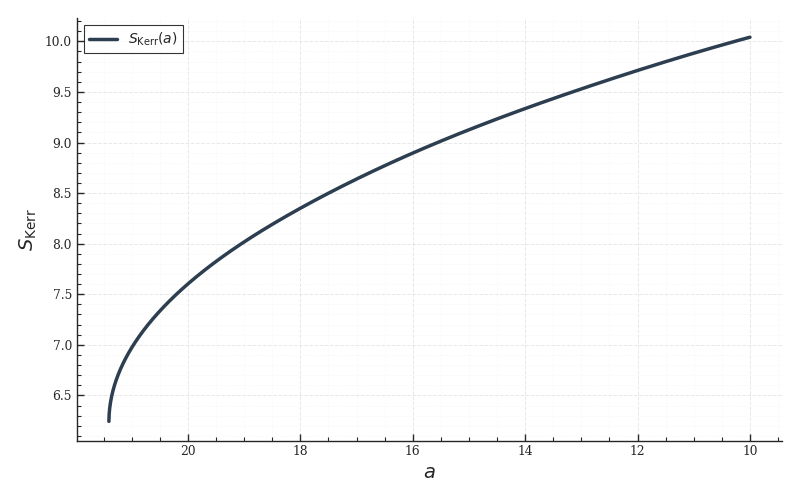

In [12]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_prec,ENT,label=r"$S_{\rm Kerr}(a)$",color="#2c3e50",lw=2.5)
ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.grid(True,which="major",linestyle="--",linewidth=0.7,alpha=0.45)
ax.minorticks_on()
ax.grid(True,which="minor",linestyle=":",linewidth=0.5,alpha=0.25)
ax.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()

### Padé $[2/1]$ extrapolation of the 2PN entropy curve

In this cell we extrapolate the 2PN entropy curve toward smaller separations using a Padé $[2/1]$ approximant. Starting from the valid 2PN data, we first select only finite and physical points satisfying

$$
a>0,
\qquad
M_{\rm tot}^{\rm 2PN}>0.
$$

The fitting data are then sorted with respect to the binary separation $a$, and the fitting variable is chosen as

$$
x = \frac{1}{\sqrt{a}},
$$

which increases as the binary separation decreases. Instead of fitting the entropy directly, we fit separately the 2PN binding energy

$$
E_{\rm bind}^{\rm 2PN}
=

M_{\rm tot}^{\rm 2PN}-m,
$$

and the dimensionless Kerr spin parameter reconstructed from the 2PN total angular momentum,

$$
\chi^{\rm 2PN}
=

\frac{J_{\rm tot}^{\rm 2PN}}
{\left(M_{\rm tot}^{\rm 2PN}\right)^2}.
$$

Only points for which both quantities are finite and satisfy the Kerr bound

$$
|\chi^{\rm 2PN}|\leq 1
$$

are retained in the fit.

Both $E_{\rm bind}^{\rm 2PN}$ and $\chi^{\rm 2PN}$ are fitted with a Padé $[2/1]$ approximant of the form

$$
P_{[2/1]}(x)
=

\frac{a_0+a_1x+a_2x^2}{1+b_1x}.
$$

The fit is performed with a robust least-squares routine using a `soft_l1` loss. A multi-start strategy is used: several initial guesses are tested, and the solution with the smallest cost is retained. The denominator coefficient is constrained by

$$
b_1 \geq 0,
$$

in order to reduce the risk of generating unstable poles in the extrapolated interval.

The weights are chosen as

$$
\sigma(a)
=

\left(
\frac{a}{a_{\min}}
\right),
$$

so that points at smaller separation, where the extrapolation is anchored, have larger statistical weight in the fit.

After the fit, the Padé models are evaluated on the extrapolation interval

$$
1 \leq a \leq 15,
$$

with

$$
x_{\rm extrap}
=
\frac{1}{\sqrt{a_{\rm extrap}}}.
$$

The extrapolated total mass and angular momentum are reconstructed as

$$
M_{\rm extrap}^{\rm 2PN}
=

m+
E_{\rm bind,extrap}^{\rm 2PN},
$$

and

$$
J_{\rm extrap}^{\rm 2PN}
=

\chi_{\rm extrap}^{\rm 2PN}
\left(
M_{\rm extrap}^{\rm 2PN}
\right)^2.
$$

The Kerr entropy is then computed from the reconstructed quantities,

$$
S_{\rm Kerr}
=

2\pi M
\left(
M+
\sqrt{
M^2-\frac{J^2}{M^2}
}
\right).
$$

Only physical extrapolated points are retained, namely those satisfying

$$
M_{\rm extrap}^{\rm 2PN}>0,
\qquad
|\chi_{\rm extrap}^{\rm 2PN}|\leq 1.
$$

The maximum of the extrapolated 2PN entropy curve defines

$$
a_{\max}^{\rm Padé,,2PN},
$$

together with the corresponding values

$$
S_{\max}^{\rm Padé,,2PN},
\qquad
M_{\max}^{\rm Padé,,2PN},
\qquad
J_{\max}^{\rm Padé,,2PN},
\qquad
\chi_{\max}^{\rm Padé,,2PN}.
$$

This separation is then compared with the merger separation predicted by the surrogate model,

$$
a_{\rm merger}^{\rm NR}.
$$

The main diagnostic quantity is therefore

$$
\Delta a
=

\left|
a_{\max}^{\rm Padé,,2PN}
-

a_{\rm merger}^{\rm NR}
\right|.
$$

This provides a direct test of whether the maximum of the 2PN Padé-extrapolated entropy curve occurs close to the surrogate merger separation. The fit costs and the number of function evaluations for both the binding-energy fit and the spin-parameter fit are also stored as diagnostics of the robustness of the extrapolation.


In [20]:
valid_mask_P = (np.isfinite(ENT)& np.isfinite(a_prec)& np.isfinite(E_tot_2PN)& np.isfinite(J_tot_2PN)& (a_prec > 0)& (E_tot_2PN > 0))
a_valid_P = a_prec[valid_mask_P]
M_valid_P = E_tot_2PN[valid_mask_P]
J_valid_P = J_tot_2PN[valid_mask_P]
S_valid_P = ENT[valid_mask_P]
sort_idx_P = np.argsort(a_valid_P)
a_fit_P = a_valid_P[sort_idx_P]
M_fit_P = M_valid_P[sort_idx_P]
J_fit_P = J_valid_P[sort_idx_P]
S_fit_P = S_valid_P[sort_idx_P]
x_fit_P = 1.0 / np.sqrt(a_fit_P)

try:
    m_ref_P = float(m1_num + m2_num)
except NameError:
    m_ref_P = 1.0

Ebind_fit_P = M_fit_P - m_ref_P
chi_fit_P = J_fit_P / M_fit_P**2
fit_mask_P = (np.isfinite(x_fit_P)& np.isfinite(Ebind_fit_P)& np.isfinite(chi_fit_P)& (np.abs(chi_fit_P) <= 1.0))
a_fit_P = a_fit_P[fit_mask_P]
x_fit_P = x_fit_P[fit_mask_P]
M_fit_P = M_fit_P[fit_mask_P]
J_fit_P = J_fit_P[fit_mask_P]
S_fit_P = S_fit_P[fit_mask_P]
Ebind_fit_P = Ebind_fit_P[fit_mask_P]
chi_fit_P = chi_fit_P[fit_mask_P]

a_min_fit_P = np.nanmin(a_fit_P)
sigma_fit_P = (a_fit_P / a_min_fit_P)**1.0


def pade_2_1_fit_P(
    x_P,
    y_P,
    sigma_P,
    y_scale_P=None,
    n_starts_P=60,
    random_seed_P=1234,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=50000,
    progress_label_P="Padé [2/1] fit"
):
    
    x_P = np.asarray(x_P, dtype=float)
    y_P = np.asarray(y_P, dtype=float)
    sigma_P = np.asarray(sigma_P, dtype=float)
    valid_P = (np.isfinite(x_P)& np.isfinite(y_P)& np.isfinite(sigma_P)& (sigma_P > 0))
    x_P = x_P[valid_P]
    y_P = y_P[valid_P]
    sigma_P = sigma_P[valid_P]
    lower_bounds_P = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds_P = np.array([ np.inf,  np.inf,  np.inf, np.inf], dtype=float)
    def residuals_P(params_P):
        y_model_P = pade_2_1(x_P, *params_P)
        res_P = (y_model_P - y_P) / sigma_P
        res_P = np.where(np.isfinite(res_P), res_P, 1.0e12)
        return res_P
    rng_P = np.random.default_rng(random_seed_P)
    starts_P = []
    starts_P.append(np.array([np.nanmedian(y_P),0.0,0.0,0.1],dtype=float))
    for _P in range(n_starts_P - 1):
        starts_P.append(np.array([np.nanmedian(y_P),rng_P.normal(loc=0.0, scale=0.2 * y_scale_P),rng_P.normal(loc=0.0, scale=0.2 * y_scale_P),rng_P.uniform(low=0.0, high=1.0)],dtype=float))
    best_result_P = None
    best_cost_P = np.inf
    last_exception_P = None
    iterator_P = tqdm(starts_P,desc=progress_label_P,total=len(starts_P),leave=True)

    for p0_P in iterator_P:
        try:
            res_P = least_squares(
                residuals_P,
                p0_P,
                bounds=(lower_bounds_P, upper_bounds_P),
                loss=loss_P,
                f_scale=f_scale_P,
                x_scale="jac",
                max_nfev=max_nfev_P
            )
            if res_P.success and np.isfinite(res_P.cost) and res_P.cost < best_cost_P:
                best_result_P = res_P
                best_cost_P = res_P.cost
            iterator_P.set_postfix(best_cost=f"{best_cost_P:.3e}")
        except Exception as exc_P:
            last_exception_P = exc_P
            iterator_P.set_postfix(error=str(exc_P)[:40])
            continue
    if best_result_P is None:
        raise RuntimeError(
            "Fit robusto fallito per Padé [2/1].\n"
            f"Ultima eccezione intercettata: {repr(last_exception_P)}"
        )
    return best_result_P.x, best_result_P

model_name_P = "Padé [2/1]"

N_STARTS_EBIND_P = 10
N_STARTS_CHI_P = 10

popt_Ebind_P, result_Ebind_P = pade_2_1_fit_P(
    x_P=x_fit_P,
    y_P=Ebind_fit_P,
    sigma_P=sigma_fit_P,
    y_scale_P=np.nanstd(Ebind_fit_P),
    n_starts_P=N_STARTS_EBIND_P,
    random_seed_P=1234,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=30000,
    progress_label_P=r"Fitting E_bind with Padé [2/1]"
)

popt_chi_P, result_chi_P = pade_2_1_fit_P(
    x_P=x_fit_P,
    y_P=chi_fit_P,
    sigma_P=sigma_fit_P,
    y_scale_P=np.nanstd(chi_fit_P),
    n_starts_P=N_STARTS_CHI_P,
    random_seed_P=4321,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=15000,
    progress_label_P=r"Fitting chi with Padé [2/1]"
)

a_extrap_P = np.linspace(15.0, 1.0, 10000)
x_extrap_P = 1.0 / np.sqrt(a_extrap_P)
Ebind_extrap_P = pade_2_1(x_extrap_P, *popt_Ebind_P)
chi_extrap_P = pade_2_1(x_extrap_P, *popt_chi_P)
M_extrap_P = m_ref_P + Ebind_extrap_P
J_extrap_P = chi_extrap_P * M_extrap_P**2

physical_mask_P = (np.isfinite(M_extrap_P)& np.isfinite(chi_extrap_P)& np.isfinite(J_extrap_P)& (M_extrap_P > 0)& (np.abs(chi_extrap_P) <= 1.0))
ENT_extrap_P = np.full_like(a_extrap_P, np.nan, dtype=float)
ENT_extrap_P[physical_mask_P] = entropy(M_extrap_P[physical_mask_P],J_extrap_P[physical_mask_P])

if np.all(np.isnan(ENT_extrap_P)):
    raise RuntimeError(
        "La curva Padé [2/1] estrapolata non contiene punti fisici validi."
    )

idx_max_P = np.nanargmax(ENT_extrap_P)
a_max_entropy_P = a_extrap_P[idx_max_P]
S_max_entropy_P = ENT_extrap_P[idx_max_P]
M_at_max_P = M_extrap_P[idx_max_P]
J_at_max_P = J_extrap_P[idx_max_P]
chi_at_max_P = chi_extrap_P[idx_max_P]
delta_a_P = np.abs(a_max_entropy_P - a_merger)
accepted_results_P = [
    {
        "model": model_name_P,
        "a_max": a_max_entropy_P,
        "S_max": S_max_entropy_P,
        "M_at_max": M_at_max_P,
        "J_at_max": J_at_max_P,
        "chi_at_max": chi_at_max_P,
        "delta_a": delta_a_P,
        "cost_Ebind": result_Ebind_P.cost,
        "cost_chi": result_chi_P.cost,
        "nfev_Ebind": result_Ebind_P.nfev,
        "nfev_chi": result_chi_P.nfev
    }
]

results_df_P = pd.DataFrame(accepted_results_P)
pade_curves_P = {
    model_name_P: {
        "a_extrap": a_extrap_P,
        "x_extrap": x_extrap_P,
        "Ebind_extrap": Ebind_extrap_P,
        "M_extrap": M_extrap_P,
        "J_extrap": J_extrap_P,
        "chi_extrap": chi_extrap_P,
        "ENT_extrap": ENT_extrap_P,
        "popt_Ebind": popt_Ebind_P,
        "popt_chi": popt_chi_P,
        "result_Ebind": result_Ebind_P,
        "result_chi": result_chi_P,
        "physical_mask": physical_mask_P
    }
}

print("============================================================")
print("PADÉ [2/1] FIT ON E_bind AND chi")
print("============================================================")
print(f"Maximum with Padé [2/1] at a = {a_max_entropy_P:.6f}")
print(f"NR Merger a                   = {a_merger:.6f}")
print(f"Delta a                       = {delta_a_P:.6f}")
print("============================================================")

Fitting E_bind with Padé [2/1]:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting chi with Padé [2/1]:   0%|          | 0/10 [00:00<?, ?it/s]

PADÉ [2/1] FIT ON E_bind AND chi
Maximum with Padé [2/1] at a = 3.507651
NR Merger a                   = 3.133806
Delta a                       = 0.373845


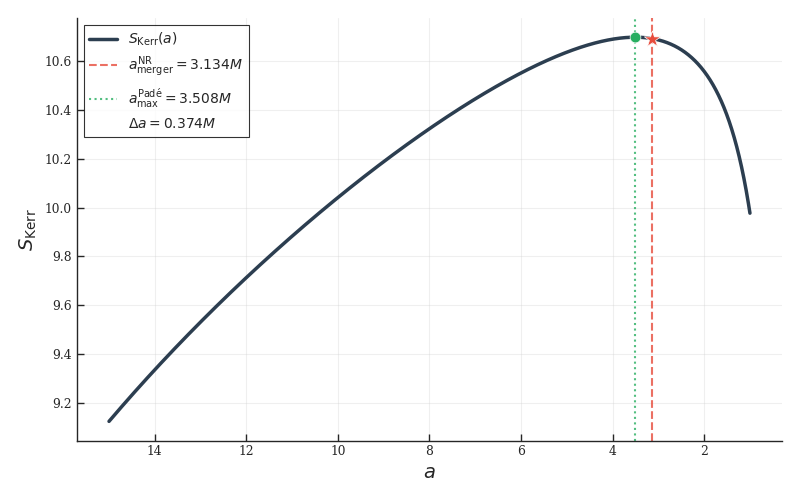

In [14]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

sort_idx_P = np.argsort(a_extrap_P)
a_sorted_P = a_extrap_P[sort_idx_P]
ent_sorted_P = ENT_extrap_P[sort_idx_P]
valid_interp_mask_P = (np.isfinite(a_sorted_P)&np.isfinite(ent_sorted_P))
a_sorted_valid_P = a_sorted_P[valid_interp_mask_P]
ent_sorted_valid_P = ent_sorted_P[valid_interp_mask_P]
y_at_merger_P = np.interp(a_merger,a_sorted_valid_P,ent_sorted_valid_P)
y_at_max_entropy_P = np.interp(a_max_entropy_P,a_sorted_valid_P,ent_sorted_valid_P)
delta_a_P = np.abs(a_max_entropy_P - a_merger)

fig_P, ax_P = plt.subplots(figsize=(8, 5))
ax_P.plot(a_extrap_P,ENT_extrap_P,label=r"$S_{\rm Kerr}(a)$",color="#2c3e50",lw=2.5)
ax_P.scatter(a_merger,y_at_merger_P,marker="*",s=150,color="#e74c3c",zorder=5,edgecolor="white",linewidth=0.5)
ax_P.scatter(a_max_entropy_P,y_at_max_entropy_P,marker="o",s=60,color="#27ae60",zorder=5,edgecolor="white",linewidth=0.5)
ax_P.axvline(a_merger,color="#e74c3c",linestyle="--",lw=1.5,alpha=0.8,label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax_P.axvline(a_max_entropy_P,color="#27ae60",linestyle=":",lw=1.5,alpha=0.8,label=fr"$a_{{\max}}^{{\rm Pad\acute{{e}}}}={a_max_entropy_P:.3f}M$")
ax_P.plot([],[]," ",label=fr"$\Delta a={delta_a_P:.3f}M$")
ax_P.invert_xaxis()
ax_P.set_xlabel(r"$a$")
ax_P.set_ylabel(r"$S_{\rm Kerr}$")
ax_P.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()

### Taylor extrapolation of the 2PN entropy curve

In this cell we extrapolate the 2PN entropy curve toward smaller separations using a Taylor polynomial model. Starting from the valid 2PN data, we first select only finite and physical points satisfying

$$
a>0,
\qquad
M_{\rm tot}^{\rm 2PN}>0.
$$

The corresponding arrays for the separation, total mass, total angular momentum and entropy are then defined as

$$
a,
\qquad
M_{\rm tot}^{\rm 2PN},
\qquad
J_{\rm tot}^{\rm 2PN},
\qquad
S_{\rm Kerr}^{\rm 2PN}.
$$

The data are sorted with respect to the binary separation $a$, and the fitting variable is chosen as

$$
x=\frac{1}{\sqrt{a}},
$$

which increases as the binary separation decreases.

As in the Padé extrapolation, the entropy is not fitted directly. Instead, we fit separately the 2PN binding energy

$$
E_{\rm bind}^{\rm 2PN}
=

M_{\rm tot}^{\rm 2PN}-m,
$$

and the dimensionless Kerr spin parameter

$$
\chi^{\rm 2PN}
=

\frac{J_{\rm tot}^{\rm 2PN}}
{\left(M_{\rm tot}^{\rm 2PN}\right)^2}.
$$

Only the points for which both quantities are finite and satisfy the Kerr bound

$$
|\chi^{\rm 2PN}|\leq 1
$$

are retained in the fit. A minimum number of valid points is also required in order to avoid performing an unreliable extrapolation.

The fitting weights are chosen as

$$
\sigma(a)
=

\left(
\frac{a}{a_{\min}}
\right),
$$

so that points at smaller separation have larger statistical weight in the fit.

The Taylor model is written in terms of the rescaled variable

$$
z
=

\frac{x-x_{\rm center}}{x_{\rm scale}},
$$

where

$$
x_{\rm center}
=

\langle x\rangle,
\qquad
x_{\rm scale}
=

{\rm std}(x).
$$

This rescaling improves the numerical conditioning of the polynomial fit. The fitted model has the form

$$
T_n(z)
=

c_0+c_1 z+c_2 z^2+\cdots+c_n z^n.
$$

In this implementation, both the binding energy and the Kerr spin parameter are fitted with cubic Taylor polynomials,

$$
T_3(z)
=

c_0+c_1 z+c_2 z^2+c_3 z^3.
$$

Therefore,

$$
E_{\rm bind}^{\rm 2PN}(x)
\simeq
T_3^{E_{\rm bind}}(z),
$$

and

$$
\chi^{\rm 2PN}(x)
\simeq
T_3^{\chi}(z).
$$

The fit is performed with a robust least-squares routine using a `soft_l1` loss. As an initial guess, a weighted polynomial fit is computed with weights proportional to $1/\sigma(a)$. The robust fit is then used to reduce the influence of possible outliers in the 2PN data.

After the fit, the Taylor models are evaluated on the extrapolation interval

$$
1\leq a \leq 15,
$$

with

$$
x_{\rm extrap}
=

\frac{1}{\sqrt{a_{\rm extrap}}}.
$$

The extrapolated total mass is reconstructed as

$$
M_{\rm extrap}^{\rm 2PN}
=

m+
E_{\rm bind,extrap}^{\rm 2PN},
$$

while the extrapolated angular momentum is reconstructed from the extrapolated Kerr spin parameter as

$$
J_{\rm extrap}^{\rm 2PN}
=

\chi_{\rm extrap}^{\rm 2PN}
\left(
M_{\rm extrap}^{\rm 2PN}
\right)^2.
$$

The Kerr entropy is then computed from the reconstructed quantities,

$$
S_{\rm Kerr}
=

2\pi M
\left(
M+
\sqrt{
M^2-\frac{J^2}{M^2}
}
\right).
$$

Only physical extrapolated points are retained, namely those satisfying

$$
M_{\rm extrap}^{\rm 2PN}>0,
\qquad
|\chi_{\rm extrap}^{\rm 2PN}|\leq 1,
\qquad
|J_{\rm extrap}^{\rm 2PN}|
\leq
\left(M_{\rm extrap}^{\rm 2PN}\right)^2.
$$

The maximum of the Taylor-extrapolated entropy curve defines

$$
a_{\max}^{\rm Taylor,,2PN},
$$

together with the corresponding values

$$
S_{\max}^{\rm Taylor,,2PN},
\qquad
M_{\max}^{\rm Taylor,,2PN},
\qquad
J_{\max}^{\rm Taylor,,2PN},
\qquad
\chi_{\max}^{\rm Taylor,,2PN}.
$$

This separation is then compared with the merger separation predicted by the surrogate model,

$$
a_{\rm merger}^{\rm NR}.
$$

The main diagnostic quantity is therefore

$$
\Delta a
=

\left|
a_{\max}^{\rm Taylor,,2PN}
-

a_{\rm merger}^{\rm NR}
\right|.
$$

This provides a direct test of whether the maximum of the Taylor-extrapolated 2PN entropy curve occurs close to the surrogate merger separation. Boundary checks are also performed: if the entropy maximum is located at the edge of the extrapolation interval, the peak may not be properly resolved and the extrapolation should be interpreted with caution. The fit costs and the number of function evaluations for both the binding-energy fit and the spin-parameter fit are stored as additional diagnostics of the robustness of the result.


In [15]:
valid_mask_T = (np.isfinite(ENT)& np.isfinite(a_prec)& np.isfinite(E_tot_2PN)& np.isfinite(J_tot_2PN)& (a_prec > 0)& (E_tot_2PN > 0))
a_valid_T = a_prec[valid_mask_T]
M_valid_T = E_tot_2PN[valid_mask_T]
J_valid_T = J_tot_2PN[valid_mask_T]
S_valid_T = ENT[valid_mask_T]
sort_idx_T = np.argsort(a_valid_T)
a_fit_T = a_valid_T[sort_idx_T]
M_fit_T = M_valid_T[sort_idx_T]
J_fit_T = J_valid_T[sort_idx_T]
S_fit_T = S_valid_T[sort_idx_T]
x_fit_T = 1.0 / np.sqrt(a_fit_T)

try:
    m_ref_T = float(m1_num + m2_num)
except NameError:
    m_ref_T = 1.0

Ebind_fit_T = M_fit_T - m_ref_T
chi_fit_T = J_fit_T / M_fit_T**2
fit_mask_T = (np.isfinite(x_fit_T)& np.isfinite(Ebind_fit_T)& np.isfinite(chi_fit_T)& (np.abs(chi_fit_T) <= 1.0))
a_fit_T = a_fit_T[fit_mask_T]
x_fit_T = x_fit_T[fit_mask_T]
M_fit_T = M_fit_T[fit_mask_T]
J_fit_T = J_fit_T[fit_mask_T]
S_fit_T = S_fit_T[fit_mask_T]
Ebind_fit_T = Ebind_fit_T[fit_mask_T]
chi_fit_T = chi_fit_T[fit_mask_T]

if len(x_fit_T) < 20:
    raise RuntimeError(
        f"Too few valid points for a reliable Taylor fit: {len(x_fit_T)}"
    )

a_min_fit_T = np.nanmin(a_fit_T)
sigma_fit_T = (a_fit_T / a_min_fit_T)**1.0

def taylor_model_scaled_T(x_T, coeffs_T, x_center_T, x_scale_T):
    
    x_T = np.asarray(x_T, dtype=float)
    z_T = (x_T - x_center_T) / x_scale_T
    y_T = np.zeros_like(z_T, dtype=float)
    for k_T, ck_T in enumerate(coeffs_T):
        y_T += ck_T * z_T**k_T
    return y_T

def taylor_fit_T(
    x_T,
    y_T,
    sigma_T,
    degree_T=3,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=50000,
    progress_label_T="Taylor fit"
):

    x_T = np.asarray(x_T, dtype=float)
    y_T = np.asarray(y_T, dtype=float)
    sigma_T = np.asarray(sigma_T, dtype=float)

    valid_T = (
        np.isfinite(x_T)
        & np.isfinite(y_T)
        & np.isfinite(sigma_T)
        & (sigma_T > 0)
    )

    x_T = x_T[valid_T]
    y_T = y_T[valid_T]
    sigma_T = sigma_T[valid_T]

    if len(x_T) <= degree_T + 1:
        raise RuntimeError(
            f"Not enough points for Taylor degree {degree_T}: "
            f"n_points = {len(x_T)}."
        )
    x_center_T = np.nanmean(x_T)
    x_scale_T = np.nanstd(x_T)
    if not np.isfinite(x_scale_T) or x_scale_T == 0.0:
        x_scale_T = 1.0

    z_T = (x_T - x_center_T) / x_scale_T
    poly_coeff_high_to_low_T = np.polyfit(z_T,y_T,deg=degree_T,w=1.0 / sigma_T)
    p0_T = poly_coeff_high_to_low_T[::-1]
    def residuals_T(coeffs_T):
        y_model_T = taylor_model_scaled_T(x_T,coeffs_T,x_center_T=x_center_T,x_scale_T=x_scale_T)
        res_T = (y_model_T - y_T) / sigma_T
        res_T = np.where(np.isfinite(res_T), res_T, 1.0e12)
        return res_T
    result_T = least_squares(residuals_T,p0_T,loss=loss_T,f_scale=f_scale_T,x_scale="jac",max_nfev=max_nfev_T)
    if not result_T.success:
        raise RuntimeError(
            f"{progress_label_T} failed: {result_T.message}"
        )
    return result_T.x, x_center_T, x_scale_T, result_T

model_name_T = "Taylor degree 3"

TAYLOR_DEGREE_EBIND_T = 3
TAYLOR_DEGREE_CHI_T = 3

coeff_Ebind_T, x_center_Ebind_T, x_scale_Ebind_T, result_Ebind_T = taylor_fit_T(
    x_T=x_fit_T,
    y_T=Ebind_fit_T,
    sigma_T=sigma_fit_T,
    degree_T=TAYLOR_DEGREE_EBIND_T,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=30000,
    progress_label_T="Fitting E_bind with Taylor"
)

coeff_chi_T, x_center_chi_T, x_scale_chi_T, result_chi_T = taylor_fit_T(
    x_T=x_fit_T,
    y_T=chi_fit_T,
    sigma_T=sigma_fit_T,
    degree_T=TAYLOR_DEGREE_CHI_T,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=15000,
    progress_label_T="Fitting chi with Taylor"
)


a_extrap_T = np.linspace(15.0, 1.0, 10000)
x_extrap_T = 1.0 / np.sqrt(a_extrap_T)

Ebind_extrap_T = taylor_model_scaled_T(x_extrap_T,coeff_Ebind_T,x_center_T=x_center_Ebind_T,x_scale_T=x_scale_Ebind_T)
chi_extrap_T = taylor_model_scaled_T(x_extrap_T,coeff_chi_T,x_center_T=x_center_chi_T,x_scale_T=x_scale_chi_T)
M_extrap_T = m_ref_T + Ebind_extrap_T
J_extrap_T = chi_extrap_T * M_extrap_T**2

physical_mask_T = (np.isfinite(M_extrap_T)& np.isfinite(chi_extrap_T)& np.isfinite(J_extrap_T)& (M_extrap_T > 0)& (np.abs(chi_extrap_T) <= 1.0)& (np.abs(J_extrap_T) <= M_extrap_T**2))
ENT_extrap_T = np.full_like(a_extrap_T, np.nan, dtype=float)
ENT_extrap_T[physical_mask_T] = entropy(M_extrap_T[physical_mask_T],J_extrap_T[physical_mask_T])

if np.all(np.isnan(ENT_extrap_T)):
    raise RuntimeError(
        "The Taylor-extrapolated curve contains no valid physical points."
    )


idx_max_T = np.nanargmax(ENT_extrap_T)
a_max_entropy_T = a_extrap_T[idx_max_T]
S_max_entropy_T = ENT_extrap_T[idx_max_T]
M_at_max_T = M_extrap_T[idx_max_T]
J_at_max_T = J_extrap_T[idx_max_T]
chi_at_max_T = chi_extrap_T[idx_max_T]
delta_a_T = np.abs(a_max_entropy_T - a_merger)

if idx_max_T == 0:
    print(
        "WARNING: Taylor entropy maximum is at the largest a boundary. "
        "The peak may not be resolved."
    )
if idx_max_T == len(a_extrap_T) - 1:
    print(
        "WARNING: Taylor entropy maximum is at the smallest a boundary. "
        "The entropy may still be increasing."
    )
if not (np.nanmin(a_extrap_T) <= a_merger <= np.nanmax(a_extrap_T)):
    print(
        f"WARNING: a_merger = {a_merger:.6f} is outside the extrapolation range "
        f"[{np.nanmin(a_extrap_T):.6f}, {np.nanmax(a_extrap_T):.6f}]."
    )


accepted_results_T = [
    {
        "model": model_name_T,
        "degree_Ebind": TAYLOR_DEGREE_EBIND_T,
        "degree_chi": TAYLOR_DEGREE_CHI_T,
        "a_max": a_max_entropy_T,
        "S_max": S_max_entropy_T,
        "M_at_max": M_at_max_T,
        "J_at_max": J_at_max_T,
        "chi_at_max": chi_at_max_T,
        "delta_a": delta_a_T,
        "cost_Ebind": result_Ebind_T.cost,
        "cost_chi": result_chi_T.cost,
        "nfev_Ebind": result_Ebind_T.nfev,
        "nfev_chi": result_chi_T.nfev
    }
]

results_taylor_df_T = pd.DataFrame(accepted_results_T)

taylor_curves_T = {
    model_name_T: {
        "a_extrap": a_extrap_T,
        "x_extrap": x_extrap_T,
        "Ebind_extrap": Ebind_extrap_T,
        "M_extrap": M_extrap_T,
        "J_extrap": J_extrap_T,
        "chi_extrap": chi_extrap_T,
        "ENT_extrap": ENT_extrap_T,
        "coeff_Ebind": coeff_Ebind_T,
        "coeff_chi": coeff_chi_T,
        "x_center_Ebind": x_center_Ebind_T,
        "x_scale_Ebind": x_scale_Ebind_T,
        "x_center_chi": x_center_chi_T,
        "x_scale_chi": x_scale_chi_T,
        "result_Ebind": result_Ebind_T,
        "result_chi": result_chi_T,
        "physical_mask": physical_mask_T
    }
}

print("============================================================")
print("TAYLOR FIT ON E_bind AND chi")
print("============================================================")
print(f"Taylor degree E_bind             = {TAYLOR_DEGREE_EBIND_T}")
print(f"Taylor degree chi                = {TAYLOR_DEGREE_CHI_T}")
print()
print(f"Maximum with Taylor at a          = {a_max_entropy_T:.6f}")
print(f"NR Merger a                       = {a_merger:.6f}")
print(f"Delta a                           = {delta_a_T:.6f}")
print("============================================================")

TAYLOR FIT ON E_bind AND chi
Taylor degree E_bind             = 3
Taylor degree chi                = 3

Maximum with Taylor at a          = 2.992399
NR Merger a                       = 3.133806
Delta a                           = 0.141406


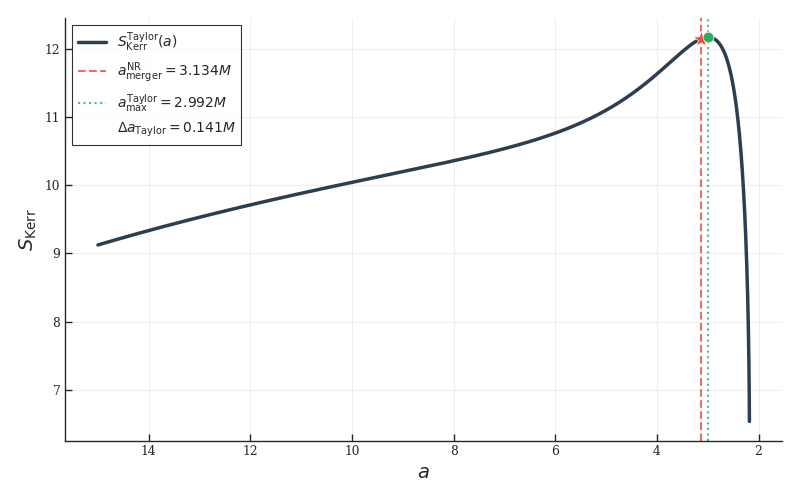

In [17]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

model_name = "Taylor degree 3"
a_taylor = taylor_curves_T[model_name]["a_extrap"]
ENT_taylor = taylor_curves_T[model_name]["ENT_extrap"]
a_max_taylor = results_taylor_df_T.loc[0, "a_max"]
S_max_taylor = results_taylor_df_T.loc[0, "S_max"]
delta_a_taylor = np.abs(a_max_taylor - a_merger)
sort_idx = np.argsort(a_taylor)
a_sorted = a_taylor[sort_idx]
ent_sorted = ENT_taylor[sort_idx]
valid_interp_mask = (np.isfinite(a_sorted)&np.isfinite(ent_sorted))
a_sorted_valid = a_sorted[valid_interp_mask]
ent_sorted_valid = ent_sorted[valid_interp_mask]
y_at_merger = np.interp(a_merger,a_sorted_valid,ent_sorted_valid)
y_at_max_taylor = np.interp(a_max_taylor,a_sorted_valid,ent_sorted_valid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_taylor,ENT_taylor,label=r"$S_{\rm Kerr}^{\rm Taylor}(a)$",color="#2c3e50",lw=2.5)
ax.scatter(a_merger,y_at_merger,marker="*",s=150,color="#e74c3c",zorder=5,edgecolor="white",linewidth=0.5)
ax.scatter(a_max_taylor,y_at_max_taylor,marker="o",s=60,color="#27ae60",zorder=5,edgecolor="white",linewidth=0.5)
ax.axvline(a_merger,color="#e74c3c",linestyle="--",lw=1.5,alpha=0.8,label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax.axvline(a_max_taylor,color="#27ae60",linestyle=":",lw=1.5,alpha=0.8,label=fr"$a_{{\max}}^{{\rm Taylor}}={a_max_taylor:.3f}M$")
ax.plot([],[]," ",label=fr"$\Delta a_{{\rm Taylor}}={delta_a_taylor:.3f}M$")
ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()